# TetheredAI MLB Model Lab — No-Lineup Feature Set

This notebook is the manual **model lab** for MLB moneyline predictions. It reads the committed project data, performs EDA, compares feature sets/models, tunes hyperparameters, evaluates calibration, tunes edge thresholds when odds history exists, and exports a champion `.joblib` model for GitHub Actions scoring.

Design choices:
- No lineup features.
- Pregame-safe rolling/expanding features only.
- Daily GitHub Action should score with the saved champion model, not retrain.
- Model selection should prioritize log loss, Brier score, calibration, AUC, and betting-edge stability over plain accuracy.


In [17]:
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, log_loss, brier_score_loss
from sklearn.inspection import permutation_importance

# Find project root whether running from notebooks/ or project root.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
for parent in [ROOT, *ROOT.parents]:
    if (parent / 'src').exists() and (parent / 'data').exists():
        ROOT = parent
        break

sys.path.insert(0, str(ROOT / 'src'))
print('Project root:', ROOT)

from mlb_betting.config import get_settings
from mlb_betting.db import connect
from mlb_betting.feature_engineering import get_model_feature_columns
from mlb_betting.modeling import (
    build_feature_sets,
    compare_models,
    probability_buckets,
    export_champion_model,
    tune_moneyline_edge_thresholds,
    add_moneyline_edges,
)


Project root: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app


## 1. Load data

The feature file should be created by `scripts/03_build_features.py`. It is sourced from `data/odds.db` tables including MLB schedule/results, pitcher boxscores, team boxscores, and odds snapshots.

In [18]:
settings = get_settings()
FEATURE_PATH = settings.data_dir / 'processed' / 'mlb_game_features.parquet'
PRED_PATH = settings.data_dir / 'predictions' / 'mlb_moneyline_predictions.csv'
DB_PATH = settings.odds_db_path

print('Feature path:', FEATURE_PATH, FEATURE_PATH.exists())
print('Predictions path:', PRED_PATH, PRED_PATH.exists())
print('DB path:', DB_PATH, DB_PATH.exists())

features = pd.read_parquet(FEATURE_PATH)
features['game_datetime_utc'] = pd.to_datetime(features['game_datetime_utc'], utc=True, errors='coerce')
print(features.shape)
display(features.head())


Feature path: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet True
Predictions path: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\predictions\mlb_moneyline_predictions.csv True
DB path: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\odds.db True
(5649, 722)


,game_pk,season,game_type,official_date,game_datetime_utc,venue_id,venue_name,home_team_id,home_team_name,home_team_norm,...,market_home_no_vig_prob,market_away_no_vig_prob,market_vig,home_spread_median,away_spread_median,home_spread_price_median,away_spread_price_median,total_points_median,over_price_median,under_price_median
0,746467,2024,R,2024-05-29,2024-05-29 16:40:00+00:00,2394,Comerica Park,116,Detroit Tigers,detroit tigers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,746468,2024,R,2024-05-29,2024-05-29 16:45:00+00:00,2394,Comerica Park,116,Detroit Tigers,detroit tigers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,746706,2024,R,2024-05-29,2024-05-29 17:10:00+00:00,2602,Great American Ball Park,113,Cincinnati Reds,cincinnati reds,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,745011,2024,R,2024-05-29,2024-05-29 18:35:00+00:00,5325,Globe Life Field,140,Texas Rangers,texas rangers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,745333,2024,R,2024-05-29,2024-05-29 19:45:00+00:00,2395,Oracle Park,137,San Francisco Giants,san francisco giants,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Dataset QA

In [19]:
completed = features[features['target_home_win'].notna()].copy()
upcoming = features[features['target_home_win'].isna()].copy()
print('Completed games:', len(completed))
print('Upcoming games:', len(upcoming))
print('Date range:', features['game_datetime_utc'].min(), '→', features['game_datetime_utc'].max())
print('Home win rate:', completed['target_home_win'].mean())

qa_cols = ['game_pk','official_date','game_datetime_utc','home_team_name','away_team_name','target_home_win','home_score','away_score']
display(features[[c for c in qa_cols if c in features.columns]].tail(20))


Completed games: 5432
Upcoming games: 217
Date range: 2024-05-29 16:40:00+00:00 → 2026-06-14 23:20:00+00:00
Home win rate: 0.5335051546391752


,game_pk,official_date,game_datetime_utc,home_team_name,away_team_name,target_home_win,home_score,away_score
5629,823776,2026-06-13,2026-06-13 23:15:00+00:00,Milwaukee Brewers,Philadelphia Phillies,NaN,NaN,NaN
5630,824100,2026-06-13,2026-06-13 23:15:00+00:00,Kansas City Royals,Houston Astros,NaN,NaN,NaN
5631,823213,2026-06-13,2026-06-14 02:05:00+00:00,San Francisco Giants,Chicago Cubs,NaN,NaN,NaN
5632,824995,2026-06-13,2026-06-14 02:05:00+00:00,Athletics,Colorado Rockies,NaN,NaN,NaN
5633,824019,2026-06-13,2026-06-14 02:07:00+00:00,Los Angeles Angels,Tampa Bay Rays,NaN,NaN,NaN
5634,823368,2026-06-14,2026-06-14 16:15:00+00:00,Pittsburgh Pirates,Miami Marlins,NaN,NaN,NaN
5635,822722,2026-06-14,2026-06-14 17:35:00+00:00,Washington Nationals,Seattle Mariners,NaN,NaN,NaN
5636,824823,2026-06-14,2026-06-14 17:35:00+00:00,Baltimore Orioles,San Diego Padres,NaN,NaN,NaN
5637,822801,2026-06-14,2026-06-14 17:37:00+00:00,Toronto Blue Jays,New York Yankees,NaN,NaN,NaN
5638,823615,2026-06-14,2026-06-14 17:40:00+00:00,New York Mets,Atlanta Braves,NaN,NaN,NaN


In [20]:
def summarize_missingness(df):
    out = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isna().sum().values,
        'missing_pct': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
    }).sort_values(['missing_pct','missing_count'], ascending=[False, False])
    return out

feature_cols_all = get_model_feature_columns(completed, include_market=False, min_non_null_rate=0.00)
miss = summarize_missingness(completed[feature_cols_all])
display(miss.head(40))


,column,missing_count,missing_pct,non_null_count
253,diff_team_box_sb_success_rate,3756,0.691458,1676
55,home_team_box_sb_success_rate,2446,0.450295,2986
154,away_team_box_sb_success_rate,2390,0.439985,3042
336,diff_team_box_sb_success_rate_last3,1071,0.197165,4361
254,diff_team_box_lob_per_run,728,0.134021,4704
138,home_team_box_sb_success_rate_last3,581,0.106959,4851
237,away_team_box_sb_success_rate_last3,565,0.104013,4867
569,diff_starter_era_season_to_date,497,0.091495,4935
570,diff_starter_whip_season_to_date,497,0.091495,4935
571,diff_starter_k_per_9_season_to_date,497,0.091495,4935


## 3. Feature group audit

This verifies that the enhanced no-lineup feature groups are present: Elo, starter, bullpen, team boxscore, and team-vs-handedness.

In [21]:
groups = {
    'elo': [c for c in features.columns if 'elo' in c.lower()],
    'starter': [c for c in features.columns if 'starter_' in c.lower()],
    'bullpen': [c for c in features.columns if 'bullpen_' in c.lower()],
    'team_box': [c for c in features.columns if 'team_box_' in c.lower()],
    'team_vs_hand': [c for c in features.columns if 'team_vs_hand' in c.lower()],
    'market': [c for c in features.columns if any(k in c.lower() for k in ['market_', 'moneyline', 'spread', 'total_points', 'vig', 'book_count'])],
}
for name, cols in groups.items():
    print(f'{name}: {len(cols)}')
    print(cols[:12])


elo: 4
['home_elo_pre', 'away_elo_pre', 'diff_elo_pre', 'elo_home_win_prob']
starter: 110
['home_starter_pitcher_name', 'home_starter_pitcher_hand', 'home_starter_games_to_date', 'home_starter_days_since_last_start', 'home_starter_era_season_to_date', 'home_starter_whip_season_to_date', 'home_starter_k_per_9_season_to_date', 'home_starter_bb_per_9_season_to_date', 'home_starter_hr_per_9_season_to_date', 'home_starter_k_minus_bb_per_bf_season_to_date', 'home_starter_ip_per_start_season_to_date', 'home_starter_pitches_per_start_season_to_date']
bullpen: 132
['home_bullpen_games_to_date', 'home_bullpen_relief_ip', 'home_bullpen_era_game', 'home_bullpen_whip_game', 'home_bullpen_k_per_9_game', 'home_bullpen_bb_per_9_game', 'home_bullpen_hr_per_9_game', 'home_bullpen_k_minus_bb_per_bf_game', 'home_bullpen_ip_last1', 'home_bullpen_pitches_last1', 'home_bullpen_batters_faced_last1', 'home_bullpen_era_last1']
team_box: 297
['home_team_box_games_to_date', 'home_team_box_xbh', 'home_team_box_bb_

## 4. Baselines

Always compare against simple baselines. A model is not useful unless it beats these on probabilistic metrics, not just accuracy.

In [22]:
y = completed['target_home_win'].astype(int).to_numpy()
home_rate = y.mean()
base_prob = np.repeat(home_rate, len(y))
print('Home win rate baseline:', home_rate)
print('Baseline log_loss:', log_loss(y, base_prob))
print('Baseline brier:', brier_score_loss(y, base_prob))


Home win rate baseline: 0.5335051546391752
Baseline log_loss: 0.6909003064659387
Baseline brier: 0.24887740461260496


## 5. Build feature sets

No market features are used for the pure baseball model. Market columns stay in the feature file for edge calculation and recommendations.

In [23]:
feature_sets = build_feature_sets(completed, min_non_null_rate=0.05)
for name, cols in feature_sets.items():
    print(name, len(cols))


baseline_team_form_elo 72
starter_only 112
baseline_starter_bullpen 310
enhanced_no_market 673
all_pure_numeric 673


## 6. Tune and compare models

This includes logistic regression, random forest, extra trees, histogram gradient boosting, SVM, and optionally XGBoost/LightGBM if installed.

Set `RUN_FULL_SEARCH = False` for fast iteration; set it to `True` for a deeper monthly/manual model run.

In [24]:
RUN_FULL_SEARCH = False
MODEL_NAMES = ['random_forest','lightgbm','xgboost','svm_rbf']

comparison = compare_models(
    completed,
    feature_sets=feature_sets,
    model_names=MODEL_NAMES,
    holdout_days=60,
    tune=True,
    calibrate=True,
    max_search_iter=80 if RUN_FULL_SEARCH else 25,
    max_cv_splits=4,
)
results = comparison['results'].copy()
valid_results = results[results['holdout_log_loss'].notna()].sort_values(['holdout_log_loss','holdout_brier'])
display(valid_results[[
    'candidate_key','feature_set','model_name','feature_count','calibration',
    'holdout_log_loss','holdout_brier','holdout_roc_auc','holdout_accuracy_50pct','holdout_avg_pred','holdout_actual_rate','best_params'
]].head(25))
print('Best key:', comparison['best_key'])


,candidate_key,feature_set,model_name,feature_count,calibration,holdout_log_loss,holdout_brier,holdout_roc_auc,holdout_accuracy_50pct,holdout_avg_pred,holdout_actual_rate,best_params
6,starter_only__xgboost,starter_only,xgboost,112,isotonic,0.687349,0.247330,0.534818,0.52875,0.541599,0.525,"{'model__subsample': 0.9, 'model__reg_lambda':..."
4,starter_only__random_forest,starter_only,random_forest,112,isotonic,0.687847,0.247388,0.540692,0.53500,0.535966,0.525,"{'model__n_estimators': 300, 'model__min_sampl..."
14,enhanced_no_market__xgboost,enhanced_no_market,xgboost,673,none,0.687935,0.247394,0.553678,0.53625,0.534628,0.525,"{'model__subsample': 0.9, 'model__reg_lambda':..."
16,all_pure_numeric__random_forest,all_pure_numeric,random_forest,673,none,0.688575,0.247722,0.548578,0.53250,0.534425,0.525,"{'model__n_estimators': 500, 'model__min_sampl..."
3,baseline_team_form_elo__lightgbm,baseline_team_form_elo,lightgbm,72,isotonic,0.688629,0.247747,0.552240,0.54750,0.536688,0.525,"{'model__subsample': 0.7, 'model__reg_lambda':..."
8,baseline_starter_bullpen__random_forest,baseline_starter_bullpen,random_forest,310,sigmoid,0.688630,0.247742,0.549612,0.54500,0.538152,0.525,"{'model__n_estimators': 500, 'model__min_sampl..."
11,baseline_starter_bullpen__lightgbm,baseline_starter_bullpen,lightgbm,310,isotonic,0.688643,0.247799,0.550407,0.53750,0.543256,0.525,"{'model__subsample': 0.7, 'model__reg_lambda':..."
0,baseline_team_form_elo__random_forest,baseline_team_form_elo,random_forest,72,isotonic,0.688685,0.247708,0.552785,0.55000,0.538312,0.525,"{'model__n_estimators': 300, 'model__min_sampl..."
18,all_pure_numeric__xgboost,all_pure_numeric,xgboost,673,none,0.688915,0.247877,0.551479,0.52000,0.534561,0.525,"{'model__subsample': 0.9, 'model__reg_lambda':..."
15,enhanced_no_market__lightgbm,enhanced_no_market,lightgbm,673,none,0.689003,0.247905,0.550501,0.53875,0.534078,0.525,"{'model__subsample': 0.7, 'model__reg_lambda':..."


Best key: starter_only__xgboost


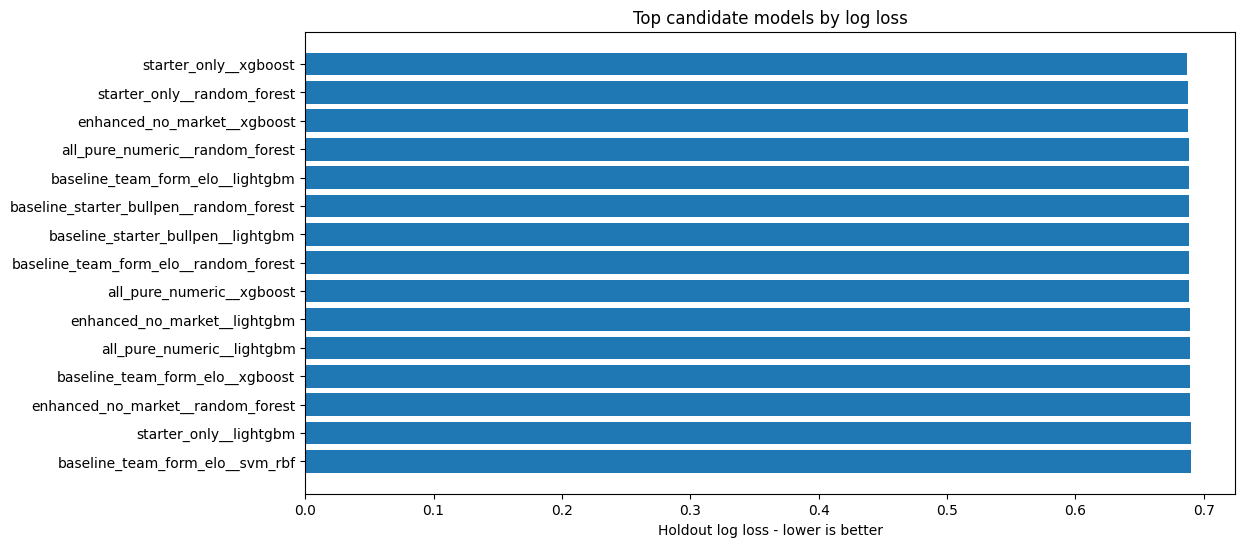

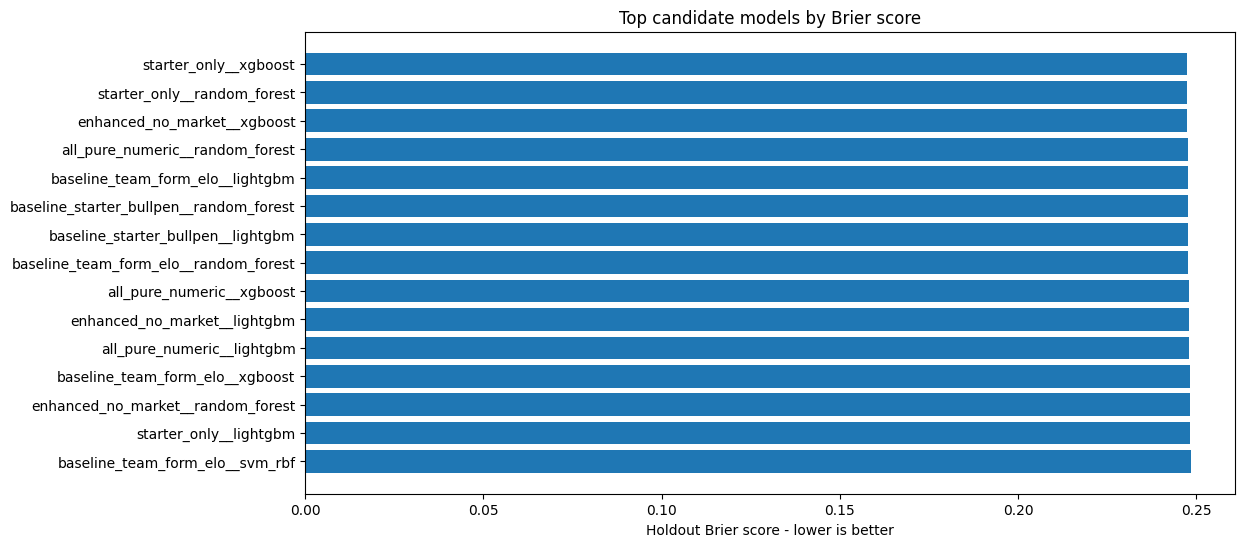

In [25]:
if len(valid_results):
    plot_df = valid_results.head(15).copy().sort_values('holdout_log_loss')
    plt.figure(figsize=(12, 6))
    plt.barh(plot_df['candidate_key'], plot_df['holdout_log_loss'])
    plt.xlabel('Holdout log loss - lower is better')
    plt.title('Top candidate models by log loss')
    plt.gca().invert_yaxis()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.barh(plot_df['candidate_key'], plot_df['holdout_brier'])
    plt.xlabel('Holdout Brier score - lower is better')
    plt.title('Top candidate models by Brier score')
    plt.gca().invert_yaxis()
    plt.show()


## 7. Best model diagnostics

Best model: starter_only__xgboost
Feature count: 112
Metrics: {'n': 800, 'log_loss': 0.6873486901486754, 'brier': 0.24733047102106964, 'accuracy_50pct': 0.52875, 'avg_pred': 0.5415991977741942, 'actual_rate': 0.525, 'roc_auc': 0.5348182957393484}
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.0, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.9}
              precision    recall  f1-score   support

           0      0.511     0.187     0.274       380
           1      0.533     0.838     0.651       420

    accuracy                          0.529       800
   macro avg      0.522     0.512     0.462       800
weighted avg      0.522     0.529     0.472       800



,pred_away,pred_home
actual_away,71,309
actual_home,68,352


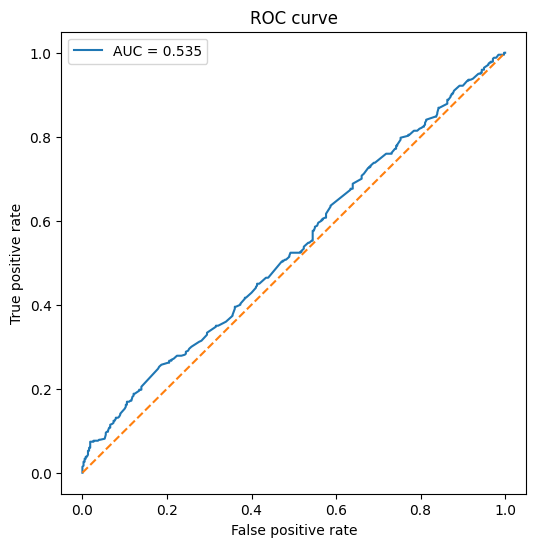

,games,avg_pred_prob,actual_home_win_rate,calibration_error
prob_bucket,,,,
"(-0.001, 0.35]",3,0.224962,0.666667,0.441704
"(0.35, 0.4]",4,0.389898,0.000000,-0.389898
"(0.4, 0.45]",16,0.426897,0.500000,0.073103
"(0.45, 0.5]",116,0.486610,0.500000,0.013390
"(0.5, 0.55]",381,0.528130,0.527559,-0.000570
"(0.55, 0.6]",200,0.568844,0.495000,-0.073844
"(0.6, 0.65]",46,0.620191,0.543478,-0.076713
"(0.65, 0.7]",22,0.674966,0.727273,0.052307
"(0.7, 1.0]",12,0.783625,0.916667,0.133042


In [26]:
best_key = comparison['best_key']
best = comparison['fitted'][best_key]
test = comparison['test'].copy()
holdout_preds = best['holdout_predictions'].copy()

y_true = holdout_preds['target_home_win'].astype(int)
y_prob = holdout_preds['model_home_win_prob'].astype(float)
y_pred = (y_prob >= 0.5).astype(int)

print('Best model:', best_key)
print('Feature count:', len(best['feature_cols']))
print('Metrics:', best['metrics'])
print('Best params:', best['best_params'])
print(classification_report(y_true, y_pred, digits=3))
display(pd.DataFrame(confusion_matrix(y_true, y_pred), index=['actual_away','actual_home'], columns=['pred_away','pred_home']))

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()

display(probability_buckets(holdout_preds, 'model_home_win_prob', target_col='target_home_win'))


## 8. Feature importance

Permutation importance can be slow. For fast iteration, reduce `n_repeats`.

,feature,importance_mean,importance_std
107,away_elo_pre,0.004896,0.002419
93,diff_starter_pitches_per_start_last5,0.001350,0.000236
82,diff_starter_hr_per_9_last3,0.000856,0.000783
58,away_starter_ip_per_start_last5,0.000703,0.000111
48,away_starter_hr_per_9_last3,0.000588,0.000729
85,diff_starter_pitches_per_start_last3,0.000569,0.000968
106,home_elo_pre,0.000545,0.000560
108,diff_elo_pre,0.000454,0.000706
47,away_starter_bb_per_9_last3,0.000453,0.000302
90,diff_starter_hr_per_9_last5,0.000441,0.000256


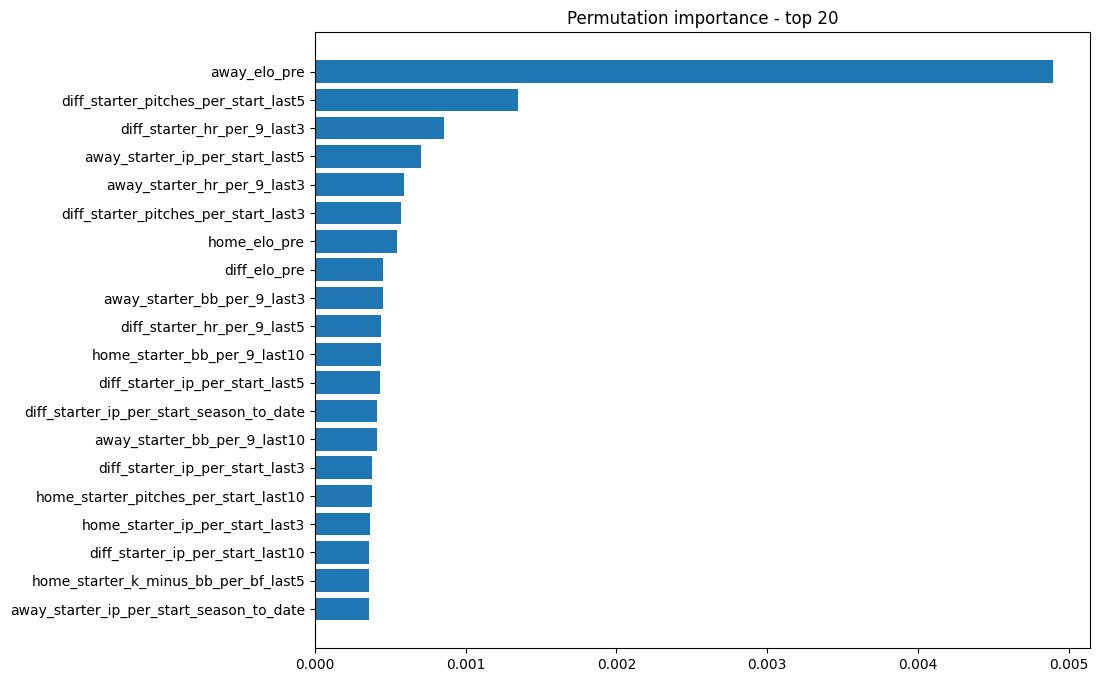

In [27]:
RUN_PERMUTATION_IMPORTANCE = True
if RUN_PERMUTATION_IMPORTANCE:
    X_test = comparison['test'][best['feature_cols']]
    y_test = comparison['test']['target_home_win'].astype(int)
    imp = permutation_importance(
        best['estimator'], X_test, y_test,
        n_repeats=5,
        random_state=42,
        scoring='neg_log_loss',
        n_jobs=-1,
    )
    imp_df = pd.DataFrame({
        'feature': best['feature_cols'],
        'importance_mean': imp.importances_mean,
        'importance_std': imp.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(imp_df.head(30))
    plt.figure(figsize=(10, 8))
    top = imp_df.head(20).sort_values('importance_mean')
    plt.barh(top['feature'], top['importance_mean'])
    plt.title('Permutation importance - top 20')
    plt.show()


## 9. Edge threshold tuning

This section only becomes meaningful once you have historical odds for completed games. Until then, it will show sparse or empty results.

In [28]:
# Join holdout predictions back to market columns from the same games, if present.
market_cols = [c for c in ['game_pk','home_moneyline_median','away_moneyline_median','market_home_no_vig_prob','market_away_no_vig_prob'] if c in completed.columns]
edge_frame = holdout_preds.merge(completed[market_cols], on='game_pk', how='left') if market_cols else holdout_preds.copy()
edge_frame = add_moneyline_edges(edge_frame)
print('Holdout rows with odds:', edge_frame[['home_moneyline_median','away_moneyline_median']].notna().all(axis=1).sum() if {'home_moneyline_median','away_moneyline_median'}.issubset(edge_frame.columns) else 0)
edge_results = tune_moneyline_edge_thresholds(edge_frame)
display(edge_results.head(20))


Holdout rows with odds: 15


,min_edge,min_ev,bets,profit_units,roi_per_unit,win_rate,max_drawdown_units
0,0.040,0.000,8,4.485556,0.560694,0.750000,2.0
1,0.040,0.005,8,4.485556,0.560694,0.750000,2.0
2,0.040,0.010,8,4.485556,0.560694,0.750000,2.0
3,0.040,0.020,8,4.485556,0.560694,0.750000,2.0
4,0.050,0.000,7,3.485556,0.497937,0.714286,2.0
5,0.050,0.005,7,3.485556,0.497937,0.714286,2.0
6,0.050,0.010,7,3.485556,0.497937,0.714286,2.0
7,0.050,0.020,7,3.485556,0.497937,0.714286,2.0
8,0.010,0.000,11,5.107142,0.464286,0.727273,3.0
9,0.010,0.005,11,5.107142,0.464286,0.727273,3.0


## 10. Upcoming prediction review

In [29]:
if PRED_PATH.exists():
    preds = pd.read_csv(PRED_PATH)
    print(preds.shape)
    display(preds.head(30))
else:
    print('No predictions file found yet:', PRED_PATH)


(195, 15)


,run_id,scored_at_utc,game_pk,official_date,game_datetime_utc,home_team_name,away_team_name,model_home_win_prob,market_home_no_vig_prob,home_moneyline_median,away_moneyline_median,recommended_side,recommended_price,edge,expected_value_per_unit
0,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,822896,2026-05-28,2026-05-29 00:05:00+00:00,Texas Rangers,Houston Astros,0.537076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,824515,2026-05-29,2026-05-29 22:40:00+00:00,Cincinnati Reds,Atlanta Braves,0.525793,0.428198,125.0,-146.0,Cincinnati Reds,125.0,0.097595,0.183035
2,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,822732,2026-05-29,2026-05-29 22:45:00+00:00,Washington Nationals,San Diego Padres,0.565891,0.494395,-105.0,-110.0,Washington Nationals,-105.0,0.071496,0.104834
3,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,823377,2026-05-29,2026-05-29 22:45:00+00:00,Pittsburgh Pirates,Minnesota Twins,0.540727,0.552957,-134.0,116.0,NaN,NaN,NaN,NaN
4,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,824835,2026-05-29,2026-05-29 23:05:00+00:00,Baltimore Orioles,Toronto Blue Jays,0.531692,0.510834,-115.0,-105.0,Baltimore Orioles,-115.0,0.020858,-0.005967
5,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,822978,2026-05-29,2026-05-29 23:10:00+00:00,Tampa Bay Rays,Los Angeles Angels,0.635560,0.618321,-180.0,152.0,NaN,NaN,NaN,NaN
6,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,823623,2026-05-29,2026-05-29 23:10:00+00:00,New York Mets,Miami Marlins,0.531692,0.525728,-119.0,104.0,NaN,NaN,NaN,NaN
7,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,824433,2026-05-29,2026-05-29 23:10:00+00:00,Cleveland Guardians,Boston Red Sox,0.529445,0.522032,-119.0,101.0,NaN,NaN,NaN,NaN
8,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,823055,2026-05-29,2026-05-29 23:15:00+00:00,St. Louis Cardinals,Chicago Cubs,0.486913,0.437228,120.0,-141.0,St. Louis Cardinals,120.0,0.049685,0.071209
9,mlb_moneyline_20260529_204042_6b2e4f98,2026-05-29T20:40:45Z,824594,2026-05-29,2026-05-29 23:40:00+00:00,Chicago White Sox,Detroit Tigers,0.540727,0.477693,102.0,-118.0,Chicago White Sox,102.0,0.063034,0.092269


## 11. Export champion model

After reviewing results, set `APPROVE_EXPORT = True` and run this cell. It overwrites:

- `models/mlb_moneyline_champion.joblib`
- `models/mlb_moneyline_champion_metadata.json`

GitHub Actions should load this stable champion artifact for scoring.

In [30]:
APPROVE_EXPORT = True

if APPROVE_EXPORT:
    metric_row = valid_results[valid_results['candidate_key'] == best_key].iloc[0].to_dict()
    export_paths = export_champion_model(
        estimator=best['estimator'],
        feature_cols=best['feature_cols'],
        metrics={k: v for k, v in metric_row.items() if k.startswith('holdout_') or k in ['cv_log_loss','calibration']},
        model_family=best['model_name'],
        feature_set_name=best['feature_set'],
        model_dir=settings.model_dir,
        notes='Manual champion selected from TetheredAI MLB model lab. No lineup features used.',
    )
    print(export_paths)
else:
    print('Set APPROVE_EXPORT=True after you have reviewed diagnostics.')


{'champion_path': WindowsPath('C:/Users/rfo7799/Desktop/Git/TetheredAI/MLB/mlb_betting_app/models/mlb_moneyline_champion.joblib'), 'metadata_path': WindowsPath('C:/Users/rfo7799/Desktop/Git/TetheredAI/MLB/mlb_betting_app/models/mlb_moneyline_champion_metadata.json'), 'archive_path': WindowsPath('C:/Users/rfo7799/Desktop/Git/TetheredAI/MLB/mlb_betting_app/models/archive/mlb_moneyline_20260531_182009_a2d8c556.joblib'), 'archive_metadata_path': WindowsPath('C:/Users/rfo7799/Desktop/Git/TetheredAI/MLB/mlb_betting_app/models/archive/mlb_moneyline_20260531_182009_a2d8c556_metadata.json')}


## 12. Champion artifact sanity check

In [31]:
from mlb_betting.modeling import load_model_bundle
champion_path = settings.model_dir / 'mlb_moneyline_champion.joblib'
if champion_path.exists():
    bundle = load_model_bundle(champion_path)
    print('Champion loaded:', champion_path)
    print('Model family:', bundle.get('model_family'))
    print('Feature set:', bundle.get('feature_set_name'))
    print('Feature count:', len(bundle['feature_cols']))
    missing = [c for c in bundle['feature_cols'] if c not in features.columns]
    print('Missing champion features in current feature file:', missing[:25], 'count=', len(missing))
else:
    print('No champion model found yet.')


Champion loaded: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\models\mlb_moneyline_champion.joblib
Model family: xgboost
Feature set: starter_only
Feature count: 112
Missing champion features in current feature file: [] count= 0
